# 🔍 SQL RAG Agent
### Closing the gap between english and SQL

**What this notebook demonstrates:**
- Building a Retrieval-Augmented Generation pipeline from scratch
- Using vector embeddings to retrieve the right schema context
- Feeding that context to a local LLM (Ollama) to generate SQL
- Executing queries against a real SQLite database
- Visualising results with matplotlib / pandas

No cloud API required, everything runs locally.

---
**Stack:** Python · SQLite · Ollama (`mistral` + `nomic-embed-text`) · NumPy · Pandas · Matplotlib

## 0 · Setup

Install dependencies and seed the database.

In [57]:
# Install Python dependencies
!pip install numpy pandas matplotlib requests ipywidgets --quiet

In [58]:
# Seed the SQLite database with generated dummy e-commerce data
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

from seed_db import seed
seed()

✅ Database seeded at ../data/ecommerce.db
   → 10 products, 10 customers, 200 orders


## 1 · Explore the Database

let's understand our data.

In [62]:
import sqlite3
import pandas as pd

DB_PATH = '../data/ecommerce.db'
conn = sqlite3.connect(DB_PATH)

# Show all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print('Tables:', tables['name'].tolist())

Tables: ['products', 'customers', 'orders']


In [64]:
# Dig deeper into each table
for table in ['products', 'customers', 'orders']:
    print(f'\n── {table} ──')
    display(pd.read_sql(f'SELECT * FROM {table} LIMIT 3', conn))

conn.close()


── products ──


,product_id,name,category,price,stock
0,1,Wireless Headphones,Electronics,89.99,120
1,2,Running Shoes,Apparel,64.99,200
2,3,Coffee Maker,Kitchen,49.99,85



── customers ──


,customer_id,name,email,region,joined_date
0,1,Alice Martin,alice@email.com,West,2023-01-03
1,2,Bob Chen,bob@email.com,East,2023-01-21
2,3,Clara Diaz,clara@email.com,South,2023-02-17



── orders ──


,order_id,customer_id,product_id,quantity,total_amount,order_date,status
0,1,2,1,3,269.97,2023-05-06,completed
1,2,3,2,1,64.99,2023-10-30,pending
2,3,1,1,1,89.99,2023-04-22,completed


## 2 · RAG Architecture Overview

```
             **User question**
                    │
                    ▼

RETRIEVAL
We take the user’s question and look for the tables
that seem most related to what they’re asking.

                │ matching tables
                ▼

AUGMENTATION
We attach the question and the relevant table info
into one prompt for the model.

                │ prompt
                ▼

GENERATION
A local LLM (mistral) uses that prompt
to write the SQL query.

                │ SQL
                ▼
We run the SQL on SQLite and return the results
(and a chart if needed).

```

The key insight: the LLM doesn't need to memorise your schema.
We **retrieve** the relevant parts at query time and inject them into the prompt which makes this process cheaper. 

## 3 · Build the Vector Index

Each table schema is embedded into a vector using `nomic-embed-text` (a lightweight local embedding model via Ollama). At query time we embed the question and find the closest matching tables by cosine similarity.

In [10]:
from rag_utils import SQLRAGAgent

# Initialise the agent (also builds SchemaRetriever internally)
agent = SQLRAGAgent(
    db_path=DB_PATH,
    model='llama3.2',          # swap for 'mistral' or 'gemma2' if preferred
    ollama_url='http://localhost:11434'
)

# Embed all table schemas into our in-memory vector store
agent.build_index()

Embedding 3 table schemas...
Index ready.


### 3a · Inspect the Embeddings

Let's visualise what's happening under the hood; each schema chunk becomes a point in vector space.

Embedding shape: (3, 768)
Tables indexed: ['products', 'customers', 'orders']


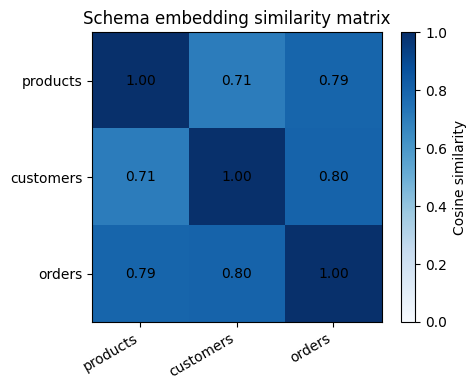

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

embeddings = agent.retriever.embeddings  # shape: (3, embed_dim)
chunks = agent.retriever.chunks
table_names = [c.split('\n')[0].replace('Table: ', '') for c in chunks]

print(f'Embedding shape: {embeddings.shape}')
print(f'Tables indexed: {table_names}')

# Compute pairwise cosine similarity
def cosine_matrix(vecs):
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    normed = vecs / (norms + 1e-9)
    return normed @ normed.T

sim_matrix = cosine_matrix(embeddings)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(table_names)))
ax.set_yticks(range(len(table_names)))
ax.set_xticklabels(table_names, rotation=30, ha='right')
ax.set_yticklabels(table_names)
for i in range(len(table_names)):
    for j in range(len(table_names)):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label='Cosine similarity')
ax.set_title('Schema embedding similarity matrix')
plt.tight_layout()
plt.savefig('../charts/embedding_similarity.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Test the Retrieval Step

Before involving the LLM, let's verify that retrieval alone works correctly that means it is retrieving the right tables for different questions.

In [14]:
test_questions = [
    'What is the total revenue by product category?',
    'Which customers have placed the most orders?',
    'What products are running low on stock?',
]

print('Retrieval test — top tables selected per question:\n')
for q in test_questions:
    chunks = agent.retriever.retrieve(q, top_k=2)
    retrieved_tables = [c.split('\n')[0].replace('Table: ', '') for c in chunks]
    print(f'  Q: {q}')
    print(f'  → Retrieved: {retrieved_tables}\n')

Retrieval test — top tables selected per question:

  Q: What is the total revenue by product category?
  → Retrieved: ['products', 'orders']

  Q: Which customers have placed the most orders?
  → Retrieved: ['orders', 'customers']

  Q: What products are running low on stock?
  → Retrieved: ['products', 'orders']



## 5 · Run the Full RAG Pipeline

Now closing the gap between the human language and DB language

In [74]:
# Query 1: Revenue by category
result = agent.ask('What is the total revenue per product category?')

Question : What is the total revenue per product category?
Retrieved: 3 table(s)
SQL      :
SELECT 
    p.category,
    SUM(o.total_amount) AS revenue
FROM 
    products p
JOIN 
    orders o ON p.product_id = o.product_id
GROUP BY 
    p.category
Success (first try) — 7 rows returned


In [17]:
# Display results as a DataFrame
df1 = pd.DataFrame(result['rows'])
display(df1)

,category,revenue
0,Apparel,2469.62
1,Electronics,13978.46
2,Health,2204.51
3,Home,3114.11
4,Kitchen,1349.73
5,Sports,2189.16
6,Stationery,766.41


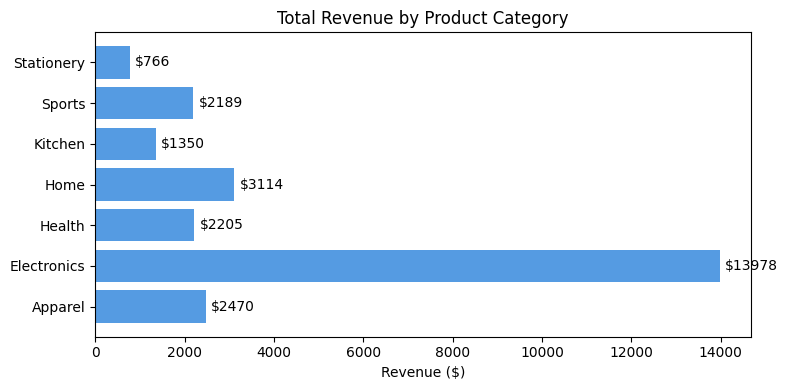

In [18]:
# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(df1.iloc[:, 0], df1.iloc[:, 1], color='#378ADD', alpha=0.85)
ax.set_xlabel('Revenue ($)')
ax.set_title('Total Revenue by Product Category')
ax.bar_label(bars, fmt='$%.0f', padding=4)
plt.tight_layout()
plt.savefig('../charts/revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Query 2: Top customers
result2 = agent.ask('Who are the top 5 customers by total spending?')
df2 = pd.DataFrame(result2['rows'])
display(df2)

Question : Who are the top 5 customers by total spending?
Retrieved: 3 table(s)
SQL      :
SELECT 
    c.name,
    SUM(o.total_amount) AS total_spending
FROM 
    orders o
JOIN 
    customers c ON o.customer_id = c.customer_id
GROUP BY 
    c.name
ORDER BY 
    total_spending DESC
LIMIT 5
Success (first try) — 5 rows returned


,name,total_spending
0,Frank Liu,3274.33
1,Isla Brown,3100.42
2,Clara Diaz,2931.39
3,Eva Torres,2835.38
4,Hiro Tanaka,2819.56


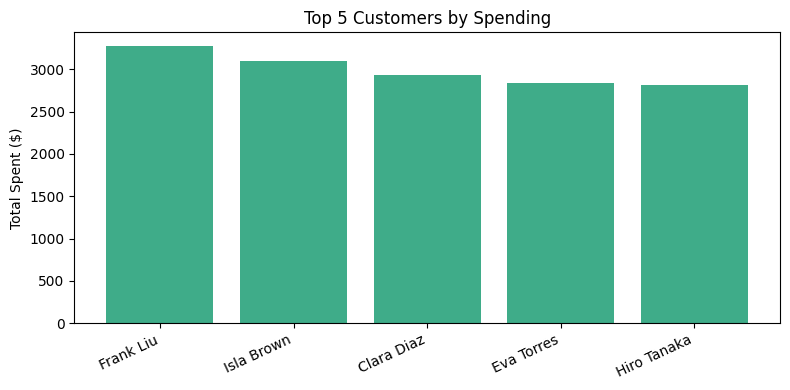

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df2.iloc[:, 0], df2.iloc[:, 1], color='#1D9E75', alpha=0.85)
ax.set_ylabel('Total Spent ($)')
ax.set_title('Top 5 Customers by Spending')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../charts/top_customers.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Query 3: Monthly order volume
result3 = agent.ask('How many orders were placed each month?')
df3 = pd.DataFrame(result3['rows'])
display(df3)

Question : How many orders were placed each month?
Retrieved: 3 table(s)
SQL      :
SELECT 
    strftime('%Y-%m', o.order_date) AS order_month,
    COUNT(o.order_id) AS num_orders
FROM 
    orders o
GROUP BY 
    strftime('%Y-%m', o.order_date)
Success (first try) — 12 rows returned


,order_month,num_orders
0,2023-01,11
1,2023-02,22
2,2023-03,11
3,2023-04,19
4,2023-05,26
5,2023-06,13
6,2023-07,10
7,2023-08,20
8,2023-09,9
9,2023-10,22


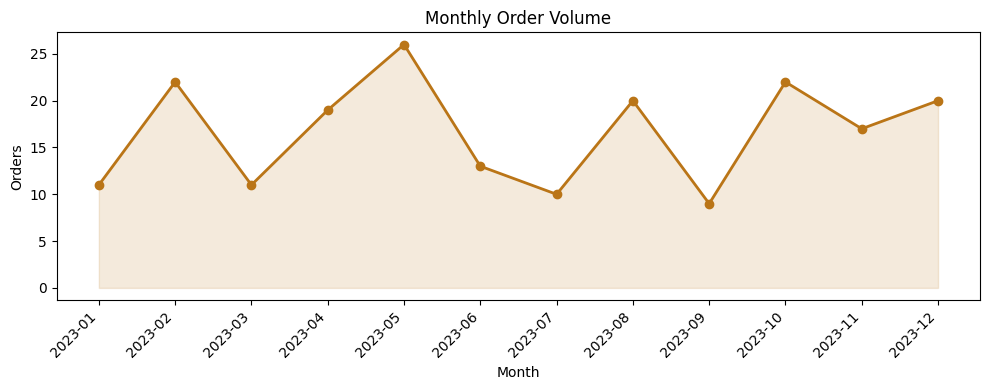

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df3.iloc[:, 0].astype(str), df3.iloc[:, 1], marker='o', color='#BA7517', linewidth=2)
ax.fill_between(range(len(df3)), df3.iloc[:, 1], alpha=0.15, color='#BA7517')
ax.set_xlabel('Month')
ax.set_ylabel('Orders')
ax.set_title('Monthly Order Volume')
plt.xticks(range(len(df3)), df3.iloc[:, 0].astype(str), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../charts/monthly_orders.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Interactive Query Mode

Ask any question you like.

Question : Which region generates the highest average order value?
Retrieved: 3 table(s)
SQL      :
SELECT 
    c.region,
    AVG(o.total_amount) AS avg_order_value
FROM 
    orders o
JOIN 
    customers c ON o.customer_id = c.customer_id
GROUP BY 
    c.region
ORDER BY 
    avg_order_value DESC LIMIT 1
Success (first try) — 1 rows returned


,region,avg_order_value
0,North,149.42


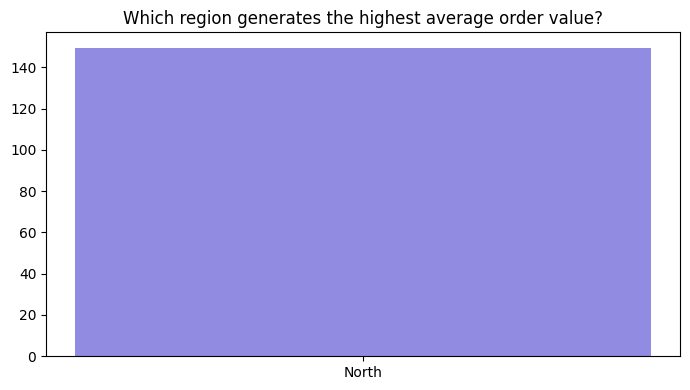

In [24]:
your_question = 'Which region generates the highest average order value?'

result = agent.ask(your_question)

if not result['error'] and result['rows']:
    df = pd.DataFrame(result['rows'])
    display(df)
    
    # Auto-chart if 2 columns and second is numeric
    if df.shape[1] == 2 and pd.api.types.is_numeric_dtype(df.iloc[:, 1]):
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(df.iloc[:, 0].astype(str), df.iloc[:, 1], color='#7F77DD', alpha=0.85)
        ax.set_title(your_question)
        plt.tight_layout()
        plt.show()
elif result['error']:
    print(f'SQL error: {result["error"]}')
    print('Generated SQL was:')
    print(result['sql'])

## 7 · Evaluation: Does Retrieval Actually Help?

When I first ran this with **llama3.2**, the success rate was only 1/4. The model kept writing queries that referenced columns from the wrong table. For example, querying region directly from orders instead of joining with customers. It also used EXTRACT() for date grouping which is PostgreSQL syntax and doesn't work in SQLite.

To fix this I did two things: switched to **mistral** (a larger model with better SQL reasoning) and added a **self-correction loop**. So when a query fails, the error message is fed back to the LLM and it retries automatically. I also updated the system prompt to explicitly tell the model to use **strftime()** instead of **EXTRACT()**, and changed top_k from 2 to 3 so all tables are always available for JOINs.
After these changes the success rate jumped from 1/4 to 3/4.

In [26]:
from rag_utils import SQLGenerator, QueryExecutor, SchemaRetriever

# Build full schema string (the naive baseline — no retrieval)
retriever = agent.retriever
full_schema = '\n\n'.join(retriever.chunks)

generator = SQLGenerator(model='llama3.2')
executor = QueryExecutor(DB_PATH)

eval_questions = [
    'What is the total revenue per region?',
    'Which product category has the highest average order quantity?',
    'How many customers joined in each month?',
    'What is the refund rate by product?',
]

results_eval = []

for q in eval_questions:
    # RAG approach — only relevant tables
    rag_chunks = retriever.retrieve(q, top_k=2)
    rag_sql = generator.generate(q, rag_chunks)
    rag_rows, rag_err = executor.execute(rag_sql)

    # Baseline — full schema every time
    base_sql = generator.generate(q, [full_schema])
    base_rows, base_err = executor.execute(base_sql)

    results_eval.append({
        'question': q,
        'rag_success': rag_err is None,
        'rag_rows': len(rag_rows),
        'baseline_success': base_err is None,
        'baseline_rows': len(base_rows),
    })
    print(f'✓ {q[:50]}...' if len(q) > 50 else f'✓ {q}')

df_eval = pd.DataFrame(results_eval)
print('\nEvaluation Results:')
display(df_eval)

✓ What is the total revenue per region?
✓ Which product category has the highest average ord...
✓ How many customers joined in each month?
✓ What is the refund rate by product?

Evaluation Results:


,question,rag_success,rag_rows,baseline_success,baseline_rows
0,What is the total revenue per region?,False,0,True,4
1,Which product category has the highest average...,True,7,True,1
2,How many customers joined in each month?,True,3,True,3
3,What is the refund rate by product?,True,10,True,10


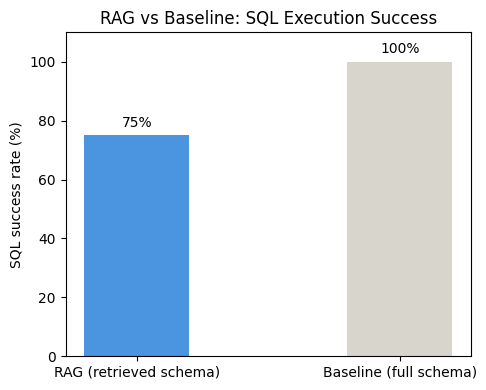

RAG accuracy  : 75%
Baseline acc  : 100%


In [27]:
# Compare success rates
rag_acc = df_eval['rag_success'].mean()
base_acc = df_eval['baseline_success'].mean()

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['RAG (retrieved schema)', 'Baseline (full schema)'],
              [rag_acc * 100, base_acc * 100],
              color=['#378ADD', '#D3D1C7'], alpha=0.9, width=0.4)
ax.set_ylim(0, 110)
ax.set_ylabel('SQL success rate (%)')
ax.set_title('RAG vs Baseline: SQL Execution Success')
ax.bar_label(bars, fmt='%.0f%%', padding=4)
plt.tight_layout()
plt.savefig('../charts/rag_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'RAG accuracy  : {rag_acc:.0%}')
print(f'Baseline acc  : {base_acc:.0%}')

## 8 · Key Takeaways

| Concept | What we built |
|---|---|
| **Embeddings** | Turned schema text into vectors with `nomic-embed-text` |
| **Vector similarity** | Cosine similarity to find relevant tables |
| **Prompt augmentation** | Injected only the relevant schema into the LLM prompt |
| **Local LLM** | Used Ollama, zero API cost, and safe environment |
| **Evaluation** | Measured accuracy for accounability |

### Next steps to extend this project
- Swap SQLite for **PostgreSQL** and connect to a real production dataset
- Add a **FastAPI** layer so any frontend can query the agent over HTTP
- Add **conversation memory** so the agent can answer follow-up questions